In [1]:
!pwd

/Users/hgkahng/Workspaces/soft-prompt/notebooks/imdb


In [2]:
import os
import sys
sys.path.insert(
    0, os.path.abspath("../../")  # two hierarchies up
)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tiktoken

from sklearn.linear_model import LogisticRegressionCV
from langchain_huggingface import HuggingFaceEmbeddings

In [3]:
TEXT: str = "review"
LABEL: str = "sentiment"

In [ ]:
# set data directory
root_dir = Path("../../").resolve()
data_dir = root_dir / "data/imdb"
print(*os.listdir(data_dir), sep='\n')

test.csv
train.csv


In [6]:
# load data
train_data = pd.read_csv(data_dir / "train.csv")
test_data = pd.read_csv(data_dir / "test.csv")

In [8]:
train_data.sample(7)

,sentiment,review
3545,positive,"rob estes, josie bisset and a crap load of kid..."
23932,negative,this movie is horrible. the acting is a waste ...
15052,negative,as an ordinary movie watcher i cannot say i en...
10984,positive,despite being told from a british perspective ...
19859,negative,"overall this movie is dreadful, and should hav..."
20590,negative,"when someone remakes a classic movie, the rema..."
16335,negative,seeing as the world snooker championship final...


In [9]:
test_data.sample(7)

,sentiment,review
17891,negative,if you like to watch movies because they are p...
4058,positive,this movie was talked about in fangoria where ...
8766,positive,this is a great horror film for people who do ...
9252,positive,blind spot one of my festival favorites. i was...
22594,negative,was this supposed to be funny? this is one of ...
16233,negative,if you want to see someone accidentally eat an...
19426,negative,i got to watch this one without commercial int...


# Length

In [11]:
encoding = tiktoken.encoding_for_model("gpt-4o")  # import tiktoken

In [12]:
# compute the number of tokens (both methods below are equivalent)
train_data['num_tokens'] = list(map(len, encoding.encode_batch(train_data['review'])))
test_data['num_tokens'] = [len(r) for r in encoding.encode_batch(test_data['review'])]

In [15]:
train_data['split'] = 'train'
test_data['split'] = 'test'

data = pd.concat([train_data, test_data], axis=0, ignore_index=True)

from IPython.display import display
display(data);

,sentiment,review,num_tokens,split
0,positive,for a movie that gets no respect there sure ar...,64,train
1,positive,bizarre horror movie filled with famous faces ...,216,train
2,positive,"a solid, if unremarkable film. matthau, as ein...",74,train
3,positive,it is a strange feeling to sit alone in a thea...,557,train
4,positive,"you probably all already know this by now, but...",176,train
...,...,...,...,...
49995,negative,with actors like depardieu and richard it is r...,140,test
49996,negative,if you like to get a couple of fleeting glimps...,201,test
49997,negative,when something can be anything you want it to ...,425,test
49998,negative,i had heard good things about states of grace ...,307,test


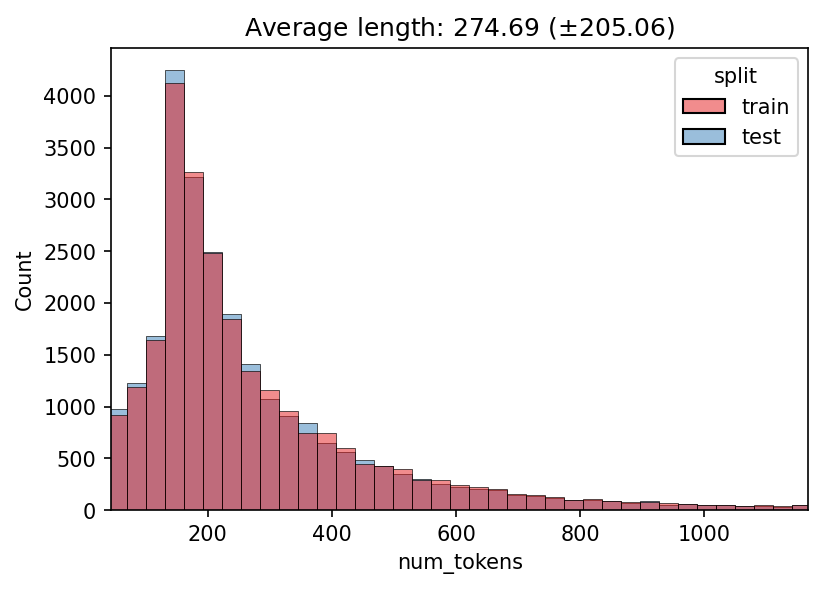

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=150)
sns.histplot(data=data, x='num_tokens', hue='split', palette="Set1", alpha=.5,
             edgecolor='k', shrink=1.0, bins=100, multiple='layer', ax=ax)
ax.set_title(
    f"Average length: {data['num_tokens'].mean():.2f} ($\pm${data['num_tokens'].std(ddof=1):.2f})"
)

# Set x-axis to show only the middle 99% of the data
lower_limit = data['num_tokens'].quantile(0.005)  #  0.5th percentile
upper_limit = data['num_tokens'].quantile(0.995)  # 99.5th percentile
ax.set_xlim(lower_limit, upper_limit)

plt.show(fig)

# Oracle Performance

### 1. Sentence Transformers
- `all-mpnet-base-v2`

In [29]:
emb_model_name = "sentence-transformers/all-mpnet-base-v2"
emb_save_dir = data_dir / f"embeddings/{emb_model_name}"

if os.path.isdir(emb_save_dir):
    
    print(f">> Loading embeddings from: {emb_save_dir}")

    # load embeddings 
    X_train = np.load(emb_save_dir / "train.features.npy")
    y_train = np.load(emb_save_dir / "train.labels.npy")
    X_test  = np.load(emb_save_dir / "test.features.npy")
    y_test  = np.load(emb_save_dir / "test.labels.npy")

else:

    print(f">> Computing embeddings with: {emb_model_name}")
    
    # instantiate embedding model
    hf_embedder = HuggingFaceEmbeddings(  # from langchain_huggingface import HuggingFaceEmbeddings
        model_name=emb_model_name,
        model_kwargs={'device': 'mps'},
        encode_kwargs={'normalize_embeddings': False},
    )

    # compute embeddings
    X_train = np.array(hf_embedder.embed_documents(train_data['review']))
    X_test = np.array(hf_embedder.embed_documents(test_data['review']))

    # labels
    label_mapper = {'positive': 1, 'negative': 0}
    y_train = train_data['sentiment'].map(label_mapper).values
    y_test = test_data['sentiment'].map(label_mapper).values

    # save them
    os.makedirs(emb_save_dir, exist_ok=False)
    with open(emb_save_dir / 'train.features.npy', 'wb') as file:
        np.save(file, X_train)

    with open(emb_save_dir / 'test.features.npy', 'wb') as file:
        np.save(file, X_test)

    with open(emb_save_dir / 'train.labels.npy', 'wb') as file:
        np.save(file, y_train)

    with open(emb_save_dir / 'test.labels.npy', 'wb') as file:
        np.save(file, y_test)

    print(f">> Saved embeddings to: {emb_save_dir}")


>> Computing embeddings with: sentence-transformers/all-mpnet-base-v2
>> Saved embeddings to: ../../data/imdb/embeddings/sentence-transformers/all-mpnet-base-v2


In [ ]:
from sklearn.linear_model import LogisticRegressionCV

def evaluate_lg(X_train: np.ndarray,
                y_train: np.ndarray,
                X_test: np.ndarray,
                y_test: np.ndarray,
                subsample_size: int = 1000,
                bootstrap: bool = True,  # sampling with replacement
                n_trials: int = 50) -> dict[str, tuple[float, float]]:

    assert X_train.shape[0] == len(y_train)

    train_acc_array = np.empty(n_trials)
    test_acc_array = np.empty_like(train_acc_array)
    
    original_idx = np.arange(X_train.shape[0])  # [0, 1, ..., len(X_train)]

    for i in range(n_trials):
        
        # get indices to use for training
        rng = np.random.default_rng(42+i)
        if bootstrap:
            use_idx = rng.choice(original_idx, size=subsample_size, replace=True)
        else:
            shuffled_idx = rng.permutation(original_idx)
            use_idx = shuffled_idx[:subsample_size]

        # fit model
        lg = LogisticRegressionCV(Cs=10, cv=5, penalty='l2',
                                  solver='lbfgs', max_iter=1000, n_jobs=8,
                                  random_state=42+i)
        lg.fit(X_train[use_idx], y_train[use_idx]);

        # evaluate
        train_acc_array[i] = lg.score(X_train[use_idx], y_train[use_idx])
        test_acc_array[i] = lg.score(X_test, y_test)

    return {
        'train_accuracy': (train_acc_array.mean(), train_acc_array.std(ddof=1)),
        'test_accuracy': (test_acc_array.mean(), test_acc_array.std(ddof=1)),
    }

In [33]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [34]:
size_to_acc = {}

subsample_sizes = [
    int(len(X_train) * r) for r in (0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00)
]
for i, subsample_size in enumerate(subsample_sizes):

    print(f">> Sample size: {subsample_size:>6,}")

    eval_result = evaluate_lg(
        X_train, y_train, X_test, y_test,
        subsample_size=subsample_size,
        bootstrap=True,
        n_trials=50,
    )

    train_acc, test_acc = \
        eval_result['train_accuracy'], eval_result['test_accuracy']

    size_to_acc[subsample_size] = eval_result

    print("\t Train acc = {:.4f} ({:.4f})".format(*train_acc))
    print("\t  Test acc = {:.4f} ({:.4f})".format(*test_acc))

>> Sample size:    250
	 Train acc = 0.9466 (0.0399)
	  Test acc = 0.8302 (0.0092)
>> Sample size:  1,250
	 Train acc = 0.9210 (0.0165)
	  Test acc = 0.8661 (0.0037)
>> Sample size:  2,500
	 Train acc = 0.9162 (0.0136)
	  Test acc = 0.8744 (0.0025)
>> Sample size:  6,250
	 Train acc = 0.9242 (0.0101)
	  Test acc = 0.8817 (0.0031)
>> Sample size: 12,500
	 Train acc = 0.9203 (0.0045)
	  Test acc = 0.8890 (0.0022)
>> Sample size: 18,750
	 Train acc = 0.9161 (0.0030)
	  Test acc = 0.8921 (0.0015)
>> Sample size: 25,000
	 Train acc = 0.9159 (0.0023)
	  Test acc = 0.8935 (0.0016)


### 2. OpenAI Embeddings
- `text-embedding-3-small`

In [35]:
import asyncio

from langchain_openai import OpenAIEmbeddings
from typing import List


async def batch_embed_documents(texts: List[str], batch_size: int = 10):
    
    # Initialize the embeddings class
    embedder = OpenAIEmbeddings(model='text-embedding-3-small')

    # Create batches of texts
    batches = [texts[i:i + batch_size] for i in range(0, len(texts), batch_size)]
    print(f">> Split {len(texts)} documents into {len(batches)} batches")
    
    embeddings = []
    
    # Process each batch
    for i, batch in enumerate(batches):
        print(f">> Processing batch {i+1:>4,}/{len(batches):>4,} ({len(batch)} documents)")
        
        # Get embeddings for the current batch
        batch_embeddings = await embedder.aembed_documents(batch)
        embeddings.extend(batch_embeddings)
        
        print(f">>  Completed batch {i+1:>4,}/{len(batches):>4,}")
        
        # Optional: Add a delay between batches to avoid rate limits
        if i < len(batches) - 1:
            await asyncio.sleep(0.5)  # 500ms delay between batches
    
    print(f">> Generated {len(embeddings):,} embeddings in total")

    return np.array(embeddings)


# # Example usage
# async def main():
#     sample_texts = [f"This is document {i}" for i in range(25)]  # 25 sample texts
#     result = await batch_embed_documents(sample_texts, batch_size=8)
#     print(f"Each embedding has {len(result[0])} dimensions")

# # Run the async function
# asyncio.run(main())

In [36]:
X_train = await batch_embed_documents(train_data['review'], batch_size=250)

>> Split 25000 documents into 100 batches
>> Processing batch    1/ 100 (250 documents)
>>  Completed batch    1/ 100
>> Processing batch    2/ 100 (250 documents)
>>  Completed batch    2/ 100
>> Processing batch    3/ 100 (250 documents)
>>  Completed batch    3/ 100
>> Processing batch    4/ 100 (250 documents)
>>  Completed batch    4/ 100
>> Processing batch    5/ 100 (250 documents)
>>  Completed batch    5/ 100
>> Processing batch    6/ 100 (250 documents)
>>  Completed batch    6/ 100
>> Processing batch    7/ 100 (250 documents)
>>  Completed batch    7/ 100
>> Processing batch    8/ 100 (250 documents)
>>  Completed batch    8/ 100
>> Processing batch    9/ 100 (250 documents)
>>  Completed batch    9/ 100
>> Processing batch   10/ 100 (250 documents)
>>  Completed batch   10/ 100
>> Processing batch   11/ 100 (250 documents)
>>  Completed batch   11/ 100
>> Processing batch   12/ 100 (250 documents)
>>  Completed batch   12/ 100
>> Processing batch   13/ 100 (250 documents)


In [37]:
print(X_train.shape)

(25000, 1536)


In [38]:
X_test = await batch_embed_documents(test_data['review'], batch_size=250)

>> Split 25000 documents into 100 batches
>> Processing batch    1/ 100 (250 documents)
>>  Completed batch    1/ 100
>> Processing batch    2/ 100 (250 documents)
>>  Completed batch    2/ 100
>> Processing batch    3/ 100 (250 documents)
>>  Completed batch    3/ 100
>> Processing batch    4/ 100 (250 documents)
>>  Completed batch    4/ 100
>> Processing batch    5/ 100 (250 documents)
>>  Completed batch    5/ 100
>> Processing batch    6/ 100 (250 documents)
>>  Completed batch    6/ 100
>> Processing batch    7/ 100 (250 documents)
>>  Completed batch    7/ 100
>> Processing batch    8/ 100 (250 documents)
>>  Completed batch    8/ 100
>> Processing batch    9/ 100 (250 documents)
>>  Completed batch    9/ 100
>> Processing batch   10/ 100 (250 documents)
>>  Completed batch   10/ 100
>> Processing batch   11/ 100 (250 documents)
>>  Completed batch   11/ 100
>> Processing batch   12/ 100 (250 documents)
>>  Completed batch   12/ 100
>> Processing batch   13/ 100 (250 documents)


In [40]:
print(X_test.shape)

(25000, 1536)


In [42]:
label_mapper = {'positive': 1, 'negative': 0}
y_train = train_data[LABEL].map(label_mapper).values
y_test = test_data[LABEL].map(label_mapper).values

In [43]:
emb_save_dir = data_dir / f"embeddings/openai/text-embedding-3-small"
os.makedirs(emb_save_dir, exist_ok=True)

with open(emb_save_dir / 'train.features.npy', 'wb') as file:
        np.save(file, X_train)

with open(emb_save_dir / 'test.features.npy', 'wb') as file:
    np.save(file, X_test)

with open(emb_save_dir / 'train.labels.npy', 'wb') as file:
    np.save(file, y_train)

with open(emb_save_dir / 'test.labels.npy', 'wb') as file:
    np.save(file, y_test)

print(f">> Saved embeddings to: {emb_save_dir}")

>> Saved embeddings to: ../../data/imdb/embeddings/openai/text-embedding-3-small


In [44]:
openai_size_to_acc = {}

subsample_sizes = [
    int(len(X_train) * r) for r in (0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00)
]
for i, subsample_size in enumerate(subsample_sizes):

    print(f">> Sample size: {subsample_size:>6,}")

    eval_result = evaluate_lg(
        X_train, y_train, X_test, y_test,
        subsample_size=subsample_size,
        bootstrap=True,
        n_trials=50,
    )

    train_acc, test_acc = \
        eval_result['train_accuracy'], eval_result['test_accuracy']

    openai_size_to_acc[subsample_size] = eval_result

    print("\t Train acc = {:.4f} ({:.4f})".format(*train_acc))
    print("\t  Test acc = {:.4f} ({:.4f})".format(*test_acc))

>> Sample size:    250
	 Train acc = 0.9719 (0.0249)
	  Test acc = 0.9159 (0.0070)
>> Sample size:  1,250
	 Train acc = 0.9660 (0.0173)
	  Test acc = 0.9309 (0.0035)
>> Sample size:  2,500
	 Train acc = 0.9612 (0.0133)
	  Test acc = 0.9349 (0.0029)
>> Sample size:  6,250
	 Train acc = 0.9655 (0.0105)
	  Test acc = 0.9371 (0.0032)
>> Sample size: 12,500
	 Train acc = 0.9665 (0.0039)
	  Test acc = 0.9381 (0.0022)
>> Sample size: 18,750
	 Train acc = 0.9654 (0.0065)
	  Test acc = 0.9356 (0.0046)
>> Sample size: 25,000
	 Train acc = 0.9554 (0.0055)
	  Test acc = 0.9414 (0.0036)


### 3. ModernBERT
- `lightonai/modernbert-embed-large`

In [45]:
!pip show huggingface_hub

Name: huggingface-hub
Version: 0.30.1
Summary: Client library to download and publish models, datasets and other repos on the huggingface.co hub
Home-page: https://github.com/huggingface/huggingface_hub
Author: Hugging Face, Inc.
Author-email: julien@huggingface.co
License: Apache
Location: /opt/miniconda3/envs/langchain/lib/python3.11/site-packages
Requires: filelock, fsspec, packaging, pyyaml, requests, tqdm, typing-extensions
Required-by: datasets, langchain-huggingface, open_clip_torch, sentence-transformers, timm, tokenizers, transformers, unstructured-inference


In [48]:
from huggingface_hub import (create_inference_endpoint,
                             list_inference_endpoints,
                             get_inference_endpoint)

model_id = "lightonai/modernbert-embed-large"  # "answerdotai/ModernBERT-large"
endpoint_name = "modernbert-large-000"
namespace = "hgkahng"  # your user or organization name

# check if endpoint with this name already exists from previous tests
available_endpoints_names = [endpoint.name for endpoint in list_inference_endpoints()]
if endpoint_name in available_endpoints_names:
    endpoint_exists = True
else:
    endpoint_exists = False
print(">> Does the endpoint already exist?", endpoint_exists)

>> Does the endpoint already exist? False


In [49]:
MAX_WORKERS = 8

if not endpoint_exists:  # create new endpoint
    endpoint = create_inference_endpoint(
        endpoint_name,
        repository=model_id,
        namespace=namespace,
        framework="pytorch",
        task="feature-extraction",  # or 'sentence-embeddings'
        # see the available hardware options here: https://huggingface.co/docs/inference-endpoints/pricing#pricing
        accelerator="gpu",
        vendor="aws",
        region="us-east-1",
        instance_size="x1",
        instance_type="nvidia-a10g",
        min_replica=0,
        max_replica=1,
        type="protected",
        # custom_image={  # https://github.com/huggingface/text-embeddings-inference?tab=readme-ov-file
        #     "health_route": "/health",
        #     "env": {
        #         "MODEL_ID": "/repository",
        #         "MAX_INPUT_LENGTH": "8192",
        #         "MAX_BATCH_TOKENS": str(MAX_WORKERS * 4096),
        #         "MAX_CONCURRENT_REQUESTS": "512",  # default
        #         #"PAYLOAD_LIMIT": str(100_000_000),  # 20mb
        #         #"POOLING": "cls",
        #         #"AUTO_TRUNCATE": "true",
        #     },
        #     "url": "ghcr.io/huggingface/text-embeddings-inference:86-1.6",
        # },
    )
    print(">> Waiting for endpoint to be created")
    endpoint.wait()
    print(">> Endpoint ready")

else:  # if endpoint with this name already exists, get and resume existing endpoint
    endpoint = get_inference_endpoint(name=endpoint_name, namespace=namespace)
    if endpoint.status in ["paused", "scaledToZero"]:
        print(">> Resuming endpoint")
        endpoint.resume()
    print(">> Waiting for endpoint to start")
    endpoint.wait()
    print(">> Endpoint ready")

>> Waiting for endpoint to be created
>> Endpoint ready


In [62]:
import asyncio
import time

from typing import Iterable
from tqdm.auto import tqdm
from tqdm.autonotebook import tqdm
from huggingface_hub import InferenceEndpoint


async def query(
        document: str,
        endpoint: InferenceEndpoint,
        semaphore: asyncio.BoundedSemaphore,
        pooling: str = 'CLS',
        ):
    
    async with semaphore:
        response = \
            await endpoint.async_client.feature_extraction(document)
    
    if pooling == 'CLS':
        return response[0][0]
    else:
        raise NotImplementedError("Work in progress...")


async def get_embeddings(
        documents: Iterable[str],
        endpoint: InferenceEndpoint,
        batch_size: int = 128
        ):
    
    # Semaphore to limit concurrent requests
    semaphore = asyncio.BoundedSemaphore(batch_size)

    # Creating a list of tasks
    tasks = [query(doc, endpoint, semaphore) for doc in documents]

    # Using tqdm with gather to show progress while waiting for all to complete
    with tqdm(total=len(tasks)) as progress_bar:
        
        # Create a list to hold the completed documents
        completed_documents = []
        
        # Process in batches to update the progress bar
        for i in range(0, len(tasks), batch_size):
            batch = tasks[i:i+batch_size]
            results = await asyncio.gather(*batch)
            completed_documents.extend(results)
            progress_bar.update(len(batch))
            time.sleep(0.05);

    return np.stack(completed_documents, axis=0)

In [68]:
X_train = await get_embeddings(train_data['review'], endpoint=endpoint, batch_size=100)

  0%|          | 0/25000 [00:00<?, ?it/s]

In [69]:
X_test = await get_embeddings(test_data['review'], endpoint=endpoint, batch_size=100)

  0%|          | 0/25000 [00:00<?, ?it/s]

In [74]:
print(model_id)

lightonai/modernbert-embed-large


In [75]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(25000, 1024) (25000, 1024)
(25000,) (25000,)


In [76]:
emb_save_dir = data_dir / f"embeddings/{model_id}"
os.makedirs(emb_save_dir, exist_ok=True)

with open(emb_save_dir / 'train.features.npy', 'wb') as file:
    np.save(file, X_train)

with open(emb_save_dir / 'test.features.npy', 'wb') as file:
    np.save(file, X_test)

with open(emb_save_dir / 'train.labels.npy', 'wb') as file:
    np.save(file, y_train)

with open(emb_save_dir / 'test.labels.npy', 'wb') as file:
    np.save(file, y_test)

print(f">> Saved embeddings to: {emb_save_dir}")

>> Saved embeddings to: ../../data/imdb/embeddings/lightonai/modernbert-embed-large


In [77]:
modernbert_size_to_acc = {}

subsample_sizes = [
    int(len(X_train) * r) for r in (0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00)
]
for i, subsample_size in enumerate(subsample_sizes):

    print(f">> Sample size: {subsample_size:>6,}")

    eval_result = evaluate_lg(
        X_train, y_train, X_test, y_test,
        subsample_size=subsample_size,
        bootstrap=True,
        n_trials=50,
    )

    train_acc, test_acc = \
        eval_result['train_accuracy'], eval_result['test_accuracy']

    modernbert_size_to_acc[subsample_size] = eval_result

    print("\t Train acc = {:.4f} ({:.4f})".format(*train_acc))
    print("\t  Test acc = {:.4f} ({:.4f})".format(*test_acc))

>> Sample size:    250
	 Train acc = 0.9786 (0.0199)
	  Test acc = 0.9197 (0.0056)
>> Sample size:  1,250
	 Train acc = 0.9648 (0.0156)
	  Test acc = 0.9319 (0.0024)
>> Sample size:  2,500
	 Train acc = 0.9628 (0.0114)
	  Test acc = 0.9357 (0.0018)
>> Sample size:  6,250
	 Train acc = 0.9635 (0.0049)
	  Test acc = 0.9393 (0.0012)
>> Sample size: 12,500


/opt/miniconda3/envs/langchain/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/miniconda3/envs/langchain/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.

	 Train acc = 0.9621 (0.0025)
	  Test acc = 0.9410 (0.0016)
>> Sample size: 18,750
	 Train acc = 0.9618 (0.0023)
	  Test acc = 0.9410 (0.0024)
>> Sample size: 25,000
	 Train acc = 0.9626 (0.0028)
	  Test acc = 0.9394 (0.0031)


### 4. ModernBERT (local)
- `lightonai/modernbert-embed-large`, but on your local machine
- Work still in progress

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("lightonai/modernbert-embed-large",
                            device="mps",
                            )

In [ ]:
from typing import Iterable

def get_embeddings(
        model: SentenceTransformer,
        docs: Iterable[str],
        batch_size: int = 32,
        ) -> np.ndarray:
    
    embeddings = []
    for i in range(0, len(docs), batch_size):
        batch = model.encode(docs[i:i+batch_size], normalize=True)
        print(f">> Computed {i+batch_size:>6,}/{len(docs):>6,} embeddings...")
        embeddings.append(batch)
    
    return np.concatenate(embeddings, axis=0)

In [ ]:
# Run this on a GPU machine (CPUs take forever)
X_train = get_embeddings(model, train_data['review'], batch_size=128)
X_test = get_embeddings(model, test_data['review'], batch_size=128)

In [78]:
from langchain_core.prompts import ChatPromptTemplate

system = " ".join(
    [
        "You are tasked with generating realistic movie reviews to train a sentiment classifier.",
        "Use a sentiment scale from 0 (negative) to 1 (positive).",
        #"Write in a natural, conversational style similar to typical online movie reviews.",
        #"Ensure varied vocabulary and phrasing. Avoid reusing identical words or phrases.",
        "Reviews should generally be between 100 and 500 words,"
        "avoiding overly short or excessively long responses.",
        "{chain_of_thought_instructions}",
        "{examples_block}",
    ]
).strip()

human = " ".join(
    [
        "Generate a movie review with a sentiment score of {score}."
    ]
)

prompt_template = ChatPromptTemplate(
    [
        ('system', system),
        ('human', human)
    ]
)

In [90]:
formatted_messages = prompt_template.format_messages(
    **{"chain_of_thought_instructions": "CoT_here\n",
       "examples_block": "examples_here\n",
       "score": "score_here"}
)

In [91]:
formatted_messages

[SystemMessage(content='You are tasked with generating realistic movie reviews to train a sentiment classifier. Use a sentiment scale from 0 (negative) to 1 (positive). Reviews should generally be between 100 and 500 words,avoiding overly short or excessively long responses. CoT_here\n examples_here\n', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Generate a movie review with a sentiment score of score_here.', additional_kwargs={}, response_metadata={})]

In [92]:
formatted_messages[0].type

'system'

In [93]:
print(formatted_messages[0].content)

You are tasked with generating realistic movie reviews to train a sentiment classifier. Use a sentiment scale from 0 (negative) to 1 (positive). Reviews should generally be between 100 and 500 words,avoiding overly short or excessively long responses. CoT_here
 examples_here

